# Part-of-Speech Tagging with Hidden Markov Models

*A lecture note on how to infer a hidden grammatical structure from a
sentence you can only observe as a bag of words in order — the sequence
labeling problem, and the classic algorithm (Viterbi decoding over a
Hidden Markov Model) built to solve it.*

---

## 1. Intro: the same word, two different jobs

Read these two sentences:

> "I read a **book** on the train."
> "Please **book** the flight for Tuesday."

`"book"` is a **noun** in the first sentence and a **verb** in the second.
Nothing about the word itself changed — same five letters, same
dictionary entry. What changed is the *context*: in the first sentence
`"book"` follows a determiner (`"a"`) and sits where a noun belongs; in
the second it follows the word `"Please"` and behaves like an action.

**Part-of-speech (POS) tagging** is the task of labeling every word in a
sentence with its grammatical category — noun, verb, adjective,
determiner, and so on — using exactly this kind of context. It sounds
like a minor bookkeeping step, but it is one of the first things almost
every classical NLP pipeline does to raw text, because so much downstream
work (parsing a sentence's grammatical structure, pulling out named
entities, building a grammar checker) depends on knowing which words are
acting as which part of speech.

The `"book"` example already tells you something important: **you cannot
tag a word correctly by looking at the word alone.** A tagger that only
ever asks "what part of speech is the string `book` *usually*?" will get
one of these two sentences wrong no matter what it picks. You have to
look at the words *around* it. That is precisely what turns POS tagging
into a **sequence labeling problem** — the tag you assign to word $i$
should depend on the tags around it, not just on word $i$ in isolation —
rather than a simple per-word classification problem you could solve with
an ordinary lookup table or classifier applied independently to each
word.

By the end of this tutorial you will be able to:

- State precisely what a **Hidden Markov Model (HMM)** is when applied to
  POS tagging: what the hidden states and observations are, and what the
  transition and emission probabilities mean.
- Derive the **Viterbi algorithm**, the dynamic-programming trick that
  finds the single most likely tag sequence for a sentence without ever
  trying all of the exponentially many possible tag sequences.
- Train an HMM tagger from scratch on real, human-annotated data (the
  Penn Treebank) and implement Viterbi decoding yourself — not call a
  black-box tagger.
- Honestly evaluate that from-scratch tagger against a real pretrained
  baseline (NLTK's built-in tagger), including where and why it loses.


## 2. The idea, intuitively

Before any formulas: here is the whole idea in one sentence.

> **Some tag sequences are far more plausible English than others, and
> some words are far more likely to carry certain tags than others — an
> HMM tagger combines both kinds of evidence to pick the single most
> plausible tag sequence for the whole sentence at once, instead of
> guessing word by word.**

Concretely, an HMM tagger leans on two separate kinds of knowledge:

- **"Which tags tend to follow which tags?"** — English grammar has
  strong local patterns: a determiner (`"the"`, `"a"`) is almost always
  followed by a noun or an adjective, not by another determiner or a
  verb. This is called a **transition** pattern — it's about the tags
  themselves, independent of which specific words they're attached to.
- **"Which words tend to get which tags?"** — the word `"the"` is
  essentially always a determiner; the word `"quickly"` is essentially
  always an adverb. This is called an **emission** pattern — how likely a
  tag is to "emit" (produce) a particular word.

Neither signal alone is enough (that's the whole `"book"` problem from
Section 1), but a word that's ambiguous on its own often becomes
unambiguous once you also demand that the *sequence* of tags around it be
grammatically plausible. Let's see that play out on real sentences, using
NLTK's shipped, pretrained tagger as a quick illustration before we build
our own from scratch.


In [1]:
import nltk

sentence_a = "I read a book on the train".split()
sentence_b = "Please book the flight for Tuesday".split()

for sentence in (sentence_a, sentence_b):
    print(nltk.pos_tag(sentence))


[('I', 'PRP'), ('read', 'VBP'), ('a', 'DT'), ('book', 'NN'), ('on', 'IN'), ('the', 'DT'), ('train', 'NN')]
[('Please', 'VB'), ('book', 'NN'), ('the', 'DT'), ('flight', 'NN'), ('for', 'IN'), ('Tuesday', 'NNP')]


Look at the tag assigned to `"book"` in each case: in the first
sentence it comes back tagged `NN` (singular noun); in the second, `VB`
(base-form verb). The tagger did not have a special rule for the word
`"book"` — it used the surrounding tags (a preceding article vs. a
preceding imperative-sentence-initial position, a following determiner
`"the"` expecting a noun after it) to disambiguate. That contextual
reasoning is exactly what an HMM + Viterbi tagger is built to do, and
we're about to build one ourselves, from the ground up, and see how well
it does.


## 3. Going deeper: the formal definition

*(This is the rigor section — if you're happy with the intuition above
and just want to see the tagger trained on real data, you can skim the
derivation and jump to Section 5. If you want to understand exactly what
the algorithm is computing and why it's efficient, read on.)*

### 3.1 Setting up the model

A **Hidden Markov Model (HMM)** applied to POS tagging treats the problem
as inference over two aligned sequences:

- A sequence of **observations** $w_1, w_2, \dots, w_n$ — the words of
  the sentence, which we actually see.
- A sequence of **hidden states** $t_1, t_2, \dots, t_n$ — the POS tags,
  which we don't see and want to recover. ("Hidden" is literally in the
  model's name for this reason: the tags are the thing generating the
  words, but we only observe the words.)

The model is fully specified by three sets of probabilities, all
estimated from data:

- **Transition probabilities** $P(t_i \mid t_{i-1})$ — given the previous
  tag, how likely is each possible next tag? These capture local grammar
  ("a determiner is usually followed by a noun or adjective").
- **Emission probabilities** $P(w_i \mid t_i)$ — given a tag, how likely
  is it to produce each possible word? These capture per-word lexical
  preference ("the tag `DT` very often emits the word `the`").
- **Initial probabilities** $P(t_1)$ — how likely is each tag to start a
  sentence. (We'll implement this as a transition from a special
  `<START>` pseudo-tag, so it's handled by the same transition table.)

### 3.2 The two independence assumptions

An HMM is *simplified on purpose* — it makes two assumptions that are not
literally true of English, but that make the model tractable to train and
decode:

1. **The Markov assumption on tags**: the current tag depends only on the
   *immediately preceding* tag, not on the whole tag history:
   $$P(t_i \mid t_1, \dots, t_{i-1}) = P(t_i \mid t_{i-1})$$
2. **The emission independence assumption**: the current word depends
   only on the *current* tag, not on any other words or any other tags:
   $$P(w_i \mid t_1, \dots, t_n, w_1, \dots, w_{i-1}, w_{i+1}, \dots, w_n) = P(w_i \mid t_i)$$

Both assumptions are simplifications — real grammar has longer-range
dependencies, and real word choice depends on more than the current tag
alone (we'll come back to exactly where this breaks in Section 7). But
together they make the joint probability of an entire tag sequence and
word sequence factor into a simple product over positions:

$$
P(t_1, \dots, t_n, w_1, \dots, w_n) \;=\; \prod_{i=1}^{n} P(t_i \mid t_{i-1}) \, P(w_i \mid t_i)
$$

with $t_0 := \texttt{<START>}$. **POS tagging is then the search for the
tag sequence that maximizes this quantity**:

$$
\hat{t}_1, \dots, \hat{t}_n = \arg\max_{t_1, \dots, t_n} \; \prod_{i=1}^{n} P(t_i \mid t_{i-1}) \, P(w_i \mid t_i)
$$

### 3.3 Why you can't just try every tag sequence

If there are $|T|$ possible tags and $n$ words in the sentence, there are
$|T|^n$ possible tag sequences. For a modest 20-word sentence with the
~35-tag Penn Treebank tag set, that's $35^{20} \approx 10^{31}$
sequences — computing the joint probability of every single one and
taking the max is completely infeasible.

### 3.4 The Viterbi algorithm

The trick is that the Markov assumption means we never actually need to
compare *whole sequences* — we only ever need to know, for each tag $t$
at each position $i$, the probability of the *single best path* that
ends in tag $t$ at position $i$. Call this quantity $V_i(t)$. Because of
the Markov assumption, $V_i(t)$ can be built up from $V_{i-1}(\cdot)$
alone:

$$
V_i(t) = \max_{t'} \; V_{i-1}(t') \cdot P(t \mid t') \cdot P(w_i \mid t)
$$

with base case $V_1(t) = P(t \mid \texttt{<START>}) \cdot P(w_1 \mid t)$.
This is a **dynamic programming recurrence**: instead of re-deriving the
best path to tag $t$ at position $i$ from scratch, we reuse the best
score already computed for every tag at position $i-1$. Alongside each
$V_i(t)$ we also store a **backpointer** — which $t'$ achieved the max —
so that once we reach the end of the sentence we can walk backpointers
from the best final tag back to position 1 and recover the actual best
tag sequence, not just its probability.

This collapses the cost from $O(|T|^n)$ (exponential in sentence length)
to $O(n \, |T|^2)$ (linear in sentence length, quadratic in tag-set size)
— at each of the $n$ positions we do $|T|^2$ work (for each of $|T|$
current tags, check all $|T|$ previous tags). That is the entire reason
Viterbi decoding is usable at all: it computes the exact global optimum
(not an approximation) in polynomial time, by exploiting the fact that
the Markov assumption lets partial solutions be reused.

### 3.5 Hand-tracing Viterbi on a tiny example

Let's make this completely concrete before touching real data. Take the
toy sentence **"the dog runs"** with a toy 3-tag set {`DET`, `NOUN`,
`VERB`} and made-up (but grammatically sensible) probabilities. We'll
build the DP table $V_i(t)$ by hand, one column (word position) at a
time, and keep every backpointer, then read off the best path.


In [2]:
import pandas as pd
import numpy as np

toy_tags = ["DET", "NOUN", "VERB"]
START = "<START>"

# Hand-picked, illustrative transition probabilities P(tag | prev_tag)
toy_trans = {
    START:  {"DET": 0.8, "NOUN": 0.15, "VERB": 0.05},
    "DET":  {"DET": 0.05, "NOUN": 0.85, "VERB": 0.10},
    "NOUN": {"DET": 0.10, "NOUN": 0.20, "VERB": 0.70},
    "VERB": {"DET": 0.35, "NOUN": 0.55, "VERB": 0.10},
}

# Hand-picked, illustrative emission probabilities P(word | tag)
toy_emit = {
    "DET":  {"the": 0.60, "dog": 0.00, "runs": 0.00},
    "NOUN": {"the": 0.00, "dog": 0.45, "runs": 0.05},
    "VERB": {"the": 0.00, "dog": 0.02, "runs": 0.35},
}

toy_sentence = ["the", "dog", "runs"]

V_table = [dict() for _ in toy_sentence]
backptr = [dict() for _ in toy_sentence]

# base case: position 0
for t in toy_tags:
    V_table[0][t] = toy_trans[START][t] * toy_emit[t][toy_sentence[0]]
    backptr[0][t] = START

# recurrence: positions 1..n-1
for i in range(1, len(toy_sentence)):
    for t in toy_tags:
        best_prev, best_score = None, -1.0
        for tp in toy_tags:
            score = V_table[i - 1][tp] * toy_trans[tp][t] * toy_emit[t][toy_sentence[i]]
            if score > best_score:
                best_score, best_prev = score, tp
        V_table[i][t] = best_score
        backptr[i][t] = best_prev

dp_display = pd.DataFrame(V_table, index=toy_sentence, columns=toy_tags).T
print("Viterbi DP table V_i(t)  (rows = tag, columns = word position)")
print(dp_display.round(5))

# termination + backtrace
best_last = max(toy_tags, key=lambda t: V_table[-1][t])
path = [best_last]
for i in range(len(toy_sentence) - 1, 0, -1):
    path.append(backptr[i][path[-1]])
path.reverse()
print("\nBest tag sequence:", list(zip(toy_sentence, path)))


Viterbi DP table V_i(t)  (rows = tag, columns = word position)
       the      dog     runs
DET   0.48  0.00000  0.00000
NOUN  0.00  0.18360  0.00184
VERB  0.00  0.00096  0.04498

Best tag sequence: [('the', 'DET'), ('dog', 'NOUN'), ('runs', 'VERB')]


Read the table column by column: at position 0 (`"the"`), `DET`
wins by a wide margin because $P(\text{the}\mid\text{DET})$ is large and
sentences overwhelmingly *start* with a determiner in this toy model —
`NOUN` and `VERB` both score exactly $0$ because their emission
probability for `"the"` was set to $0$. At position 1 (`"dog"`), the
recurrence only ever extends from the position-0 scores, weighted by
transition probability into each tag and then by the emission
probability of `"dog"` under that tag — `NOUN` wins because `DET -> NOUN`
is a common transition *and* `"dog"` is a plausible noun emission. At
position 2 (`"runs"`), `VERB` wins for the same reason: `NOUN -> VERB` is
the dominant transition and `"runs"` is overwhelmingly a verb emission
here. The backtrace then reads `DET -> NOUN -> VERB`, i.e. `("the", DET),
("dog", NOUN), ("runs", VERB)` — exactly the correct tagging, recovered
without ever computing the probability of any tag sequence *other* than
the ones that survive at each step. That pruning-as-you-go is the whole
efficiency story of Viterbi in miniature.


## 4. Visuals: what a transition matrix looks like

Before moving to real data, it's worth looking at what the *complete*
transition-probability table looks like as a heatmap, since that's the
object the Viterbi recurrence leans on at every single step. Here's the
toy 4x4 transition matrix (including `<START>`) from Section 3.5,
visualized — this is a small preview of the much bigger, real version
we'll learn from the Penn Treebank in Section 5.


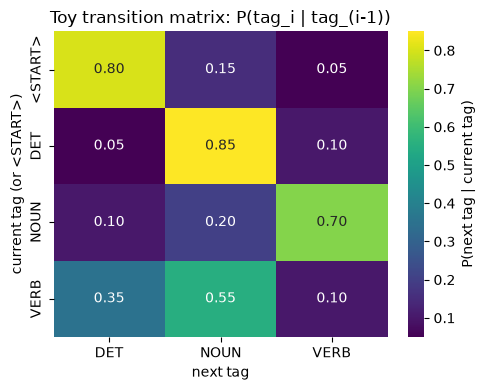

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

toy_trans_matrix = pd.DataFrame(toy_trans).T[toy_tags].reindex([START] + toy_tags)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(toy_trans_matrix, annot=True, fmt=".2f", cmap="viridis",
            cbar_kws={"label": "P(next tag | current tag)"}, ax=ax)
ax.set_title("Toy transition matrix: P(tag_i | tag_(i-1))")
ax.set_xlabel("next tag")
ax.set_ylabel("current tag (or <START>)")
plt.tight_layout()
plt.show()


Notice the bright cell at `<START> -> DET`: sentences in this toy
model overwhelmingly start with a determiner, and the bright
`DET -> NOUN` and `NOUN -> VERB` cells encode "a determiner is usually
followed by a noun" and "a noun is usually followed by a verb" — exactly
the grammatical regularities Viterbi exploited above. This is a
made-up 3-tag example; in Section 5 we'll learn a real ~35-tag version of
this exact matrix from real annotated English text and see whether the
same kind of structure shows up.


## 5. Implementation: training and decoding on the real Penn Treebank

Now for the real thing. We'll use the **Penn Treebank** sample bundled
with NLTK: 3,914 sentences of real Wall Street Journal text, manually
annotated with part-of-speech tags by professional linguists (the
canonical POS-tagging benchmark; see Marcus, Marcinkiewicz & Santorini,
1993, in References). We'll:

1. Split it into train/test sentences.
2. Estimate transition and emission probabilities from the training data
   by **maximum likelihood estimation (MLE)** — just counting — with
   **add-k smoothing** so unseen (tag, tag) and (tag, word) pairs don't
   get probability exactly zero.
3. Implement the Viterbi decoder from scratch (the same recurrence as
   Section 3.4, now over the real ~35-tag set and a real vocabulary).
4. Run it on held-out test sentences never seen during training and
   report real accuracy, a per-tag breakdown, and a confusion matrix.
5. Compare against NLTK's built-in pretrained tagger as a sanity-check
   baseline.

### 5.1 Loading and splitting the data


In [4]:
import nltk
from nltk.corpus import treebank
from collections import Counter, defaultdict
import random

nltk_sents_raw = treebank.tagged_sents()
print(f"Total tagged sentences in the NLTK Penn Treebank sample: {len(nltk_sents_raw)}")
print("Example sentence (raw):")
print(nltk_sents_raw[0])


Total tagged sentences in the NLTK Penn Treebank sample: 3914
Example sentence (raw):
[('Pierre', 'NNP'), ('Vinken', 'NNP'), (',', ','), ('61', 'CD'), ('years', 'NNS'), ('old', 'JJ'), (',', ','), ('will', 'MD'), ('join', 'VB'), ('the', 'DT'), ('board', 'NN'), ('as', 'IN'), ('a', 'DT'), ('nonexecutive', 'JJ'), ('director', 'NN'), ('Nov.', 'NNP'), ('29', 'CD'), ('.', '.')]


The raw corpus includes a special tag, `-NONE-`, marking empty
*trace* elements the original Treebank annotators used for things like
elided subjects in syntax trees (e.g. `*-1`) — these aren't real words a
tagger would ever see at inference time, so we filter them out before
doing anything else.


In [5]:
def strip_traces(sent):
    return [(w, t) for w, t in sent if t != "-NONE-"]

all_sents = [strip_traces(s) for s in nltk_sents_raw]
all_sents = [s for s in all_sents if s]  # drop any now-empty sentences

random.seed(42)
indices = list(range(len(all_sents)))
random.shuffle(indices)
split_point = int(0.8 * len(indices))
train_idx, test_idx = indices[:split_point], indices[split_point:]

train_sents = [all_sents[i] for i in train_idx]
test_sents = [all_sents[i] for i in test_idx]

n_train_tokens = sum(len(s) for s in train_sents)
n_test_tokens = sum(len(s) for s in test_sents)
print(f"Train: {len(train_sents)} sentences, {n_train_tokens:,} tokens")
print(f"Test:  {len(test_sents)} sentences, {n_test_tokens:,} tokens")


Train: 3131 sentences, 75,688 tokens
Test:  783 sentences, 18,396 tokens


### 5.2 Estimating transition and emission probabilities (MLE + add-k smoothing)

The MLE estimates are simple counts and count ratios:

$$
P_{\text{MLE}}(t_i \mid t_{i-1}) = \frac{\text{count}(t_{i-1}, t_i)}{\text{count}(t_{i-1})}
\qquad\qquad
P_{\text{MLE}}(w_i \mid t_i) = \frac{\text{count}(t_i, w_i)}{\text{count}(t_i)}
$$

The problem with raw MLE: any (tag, tag) transition or (tag, word)
emission that never appears in training gets probability exactly $0$,
which would make Viterbi discard an entire tag sequence just because it
contains one word the model has never seen — even if every other choice
is terrible. This is the exact same **zero-probability problem** the
n-gram language model tutorial in this domain runs into with unseen word
sequences, and the fix is the same: **add-k smoothing**, which reserves a
small amount of probability mass for unseen events by adding a constant
$k$ to every count before normalizing:

$$
P_{\text{add-}k}(t_i \mid t_{i-1}) = \frac{\text{count}(t_{i-1}, t_i) + k}{\text{count}(t_{i-1}) + k \cdot (|T| + 1)}
\qquad\qquad
P_{\text{add-}k}(w_i \mid t_i) = \frac{\text{count}(t_i, w_i) + k}{\text{count}(t_i) + k \cdot |V|}
$$

where $|T|$ is the number of tags (the $+1$ accounts for the `<END>`
transition target) and $|V|$ is the vocabulary size (including one slot
for unseen/`<UNK>` words). We'll use $k = 0.1$, and work in log-space
throughout the Viterbi implementation to avoid numerical underflow from
multiplying many small probabilities together.


In [6]:
START = "<START>"
END = "<END>"
K = 0.1  # add-k smoothing constant

tag_set = sorted(set(t for s in train_sents for _, t in s))
n_tags = len(tag_set)

transition_counts = defaultdict(Counter)  # transition_counts[prev_tag][tag] = count
emission_counts = defaultdict(Counter)    # emission_counts[tag][word] = count
tag_totals = Counter()
vocabulary = set()

for sent in train_sents:
    prev_tag = START
    for word, tag in sent:
        word_lc = word.lower()
        transition_counts[prev_tag][tag] += 1
        emission_counts[tag][word_lc] += 1
        tag_totals[tag] += 1
        vocabulary.add(word_lc)
        prev_tag = tag
    transition_counts[prev_tag][END] += 1

vocab_size = len(vocabulary) + 1  # +1 for <UNK>
print(f"Tag set size |T| = {n_tags}")
print(f"Vocabulary size |V| = {vocab_size:,} (including <UNK>)")
print(f"Tags: {tag_set}")


def log_transition_prob(prev_tag, tag):
    numerator = transition_counts[prev_tag][tag] + K
    denominator = sum(transition_counts[prev_tag].values()) + K * (n_tags + 1)
    return np.log(numerator / denominator)


def log_emission_prob(tag, word_lc):
    numerator = emission_counts[tag][word_lc] + K
    denominator = tag_totals[tag] + K * vocab_size
    return np.log(numerator / denominator)


Tag set size |T| = 45
Vocabulary size |V| = 9,726 (including <UNK>)
Tags: ['#', '$', "''", ',', '-LRB-', '-RRB-', '.', ':', 'CC', 'CD', 'DT', 'EX', 'FW', 'IN', 'JJ', 'JJR', 'JJS', 'LS', 'MD', 'NN', 'NNP', 'NNPS', 'NNS', 'PDT', 'POS', 'PRP', 'PRP$', 'RB', 'RBR', 'RBS', 'RP', 'SYM', 'TO', 'UH', 'VB', 'VBD', 'VBG', 'VBN', 'VBP', 'VBZ', 'WDT', 'WP', 'WP$', 'WRB', '``']


### 5.3 The Viterbi decoder, from scratch

This is a direct, literal implementation of the recurrence from Section
3.4 — same base case, same recurrence, same backpointer-based
backtrace — just running in log-space (so products become sums) and over
the real tag set instead of the 3-tag toy example.


In [7]:
def viterbi_decode(words):
    n = len(words)
    words_lc = [w.lower() for w in words]

    V_table = [dict() for _ in range(n)]
    backptr = [dict() for _ in range(n)]

    # base case: position 0
    for tag in tag_set:
        V_table[0][tag] = log_transition_prob(START, tag) + log_emission_prob(tag, words_lc[0])
        backptr[0][tag] = None

    # recurrence: positions 1..n-1
    for i in range(1, n):
        emit_cache = {tag: log_emission_prob(tag, words_lc[i]) for tag in tag_set}
        for tag in tag_set:
            best_prev_tag, best_score = None, -np.inf
            for prev_tag in tag_set:
                score = V_table[i - 1][prev_tag] + log_transition_prob(prev_tag, tag) + emit_cache[tag]
                if score > best_score:
                    best_score, best_prev_tag = score, prev_tag
            V_table[i][tag] = best_score
            backptr[i][tag] = best_prev_tag

    # termination: best final tag
    best_last_tag = max(tag_set, key=lambda t: V_table[n - 1][t])

    # backtrace
    path = [best_last_tag]
    for i in range(n - 1, 0, -1):
        path.append(backptr[i][path[-1]])
    path.reverse()
    return path


# sanity check on one real test sentence
example_words = [w for w, _ in test_sents[0]]
example_gold = [t for _, t in test_sents[0]]
example_pred = viterbi_decode(example_words)
print("Words: ", example_words)
print("Gold:  ", example_gold)
print("Viterbi:", example_pred)


Words:  ['Terms', 'were', "n't", 'disclosed', '.']
Gold:   ['NNS', 'VBD', 'RB', 'VBN', '.']
Viterbi: ['NNS', 'VBD', 'RB', 'VBN', '.']


### 5.4 Evaluating on the full held-out test set

Now we run the from-scratch Viterbi decoder on every test sentence — real
Wall Street Journal sentences the model never saw during training — and
compare its predicted tag for every single word against the gold
(human-annotated) tag.


In [8]:
tag_correct = Counter()
tag_total = Counter()
confusion_counts = Counter()  # (gold_tag, predicted_tag) -> count
total_correct = 0
total_tokens = 0

for sent in test_sents:
    words = [w for w, _ in sent]
    gold_tags = [t for _, t in sent]
    predicted_tags = viterbi_decode(words)

    for gold, pred in zip(gold_tags, predicted_tags):
        total_tokens += 1
        tag_total[gold] += 1
        if gold == pred:
            total_correct += 1
            tag_correct[gold] += 1
        else:
            confusion_counts[(gold, pred)] += 1

hmm_accuracy = total_correct / total_tokens
print(f"From-scratch HMM + Viterbi accuracy: {hmm_accuracy:.4f} "
      f"({total_correct:,} / {total_tokens:,} tokens)")


From-scratch HMM + Viterbi accuracy: 0.9031 (16,613 / 18,396 tokens)


### 5.5 Per-tag accuracy and the confusion matrix

Overall accuracy hides a lot. Some tags are essentially unambiguous
(punctuation, determiners); others are genuinely hard even for
professional linguists to agree on. Let's break accuracy down per tag,
and look at exactly which tag pairs get confused for each other most
often.


In [9]:
per_tag_rows = []
for tag in tag_set:
    if tag_total[tag] > 0:
        per_tag_rows.append({
            "tag": tag,
            "support": tag_total[tag],
            "accuracy": tag_correct[tag] / tag_total[tag],
        })

per_tag_df = pd.DataFrame(per_tag_rows).sort_values("support", ascending=False).reset_index(drop=True)
print("Per-tag accuracy (sorted by frequency in test set):")
print(per_tag_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))


Per-tag accuracy (sorted by frequency in test set):
  tag  support  accuracy
   NN     2548     0.869
   IN     1933     0.979
  NNP     1877     0.822
   DT     1583     0.989
  NNS     1188     0.891
   JJ     1138     0.817
    ,      938     1.000
    .      773     1.000
   CD      647     0.858
  VBD      630     0.856
   RB      575     0.870
   VB      487     0.916
  VBN      439     0.804
   CC      434     0.993
   TO      426     1.000
  VBZ      396     0.891
  PRP      329     0.988
  VBG      299     0.672
  VBP      261     0.793
  POS      167     0.982
   MD      164     0.994
 PRP$      160     0.988
    $      138     1.000
   ``      137     1.000
   ''      135     0.985
  WDT       93     0.871
    :       85     0.988
  JJR       83     0.892
 NNPS       52     0.173
   RP       46     0.500
  WRB       43     0.953
   WP       43     0.977
  JJS       35     0.943
  RBR       28     0.321
-RRB-       27     0.926
-LRB-       24     1.000
   EX       17     0.82

In [10]:
print("Most commonly confused (gold -> predicted) tag pairs:")
confusion_df = pd.DataFrame(
    [(g, p, c) for (g, p), c in confusion_counts.most_common(15)],
    columns=["gold_tag", "predicted_tag", "count"],
)
print(confusion_df.to_string(index=False))


Most commonly confused (gold -> predicted) tag pairs:
gold_tag predicted_tag  count
     NNP            NN    120
      NN           NNP     90
      NN           NNS     67
     NNP            JJ     63
      NN            JJ     59
     VBD           VBN     33
      JJ           VBN     29
     VBN           VBD     29
      JJ           NNP     29
     NNS            NN     27
     NNP            DT     27
      JJ            DT     26
      JJ            NN     24
     VBP            VB     23
      IN            RB     21


On this run, the from-scratch HMM tagger reaches **90.3% token
accuracy** (16,613 / 18,396 correct) on 783 held-out test sentences.
Looking at the confusion pairs, the errors are not random — they cluster
around exactly the distinctions linguists themselves find hardest:

- **`NNP` (proper noun) vs. `NN` (common noun)** is the single most
  common confusion in both directions (`NNP -> NN`: 120, `NN -> NNP`: 90).
  This makes sense given the model's independence assumptions: whether a
  word is a proper noun is signaled heavily by *capitalization*, but our
  model lowercases every word before looking it up, throwing that signal
  away entirely, and an unfamiliar capitalized word only has the (much
  weaker) transition context to fall back on.
- **`NN` vs. `NNS`** (singular vs. plural common noun, 67 errors) and
  **`NN` vs. `JJ`** (noun vs. adjective, 59 errors) reflect real
  structural ambiguity in English noun phrases (e.g. a word used
  attributively, like `"steel"` in `"steel factory"`, can look like
  either a noun-as-modifier or an adjective).
- **`VBD` vs. `VBN`** (past tense vs. past participle, 33 + 29 errors) is
  a classically hard pair even for people: `"the door was closed"` can
  mean the passive-voice past participle (`VBN`, describing a resulting
  state) or, out of context, look like simple past tense (`VBD`) —
  telling them apart requires exactly the kind of longer-range syntactic
  reasoning a first-order HMM does not have access to.

None of these are bugs — they're the predictable consequence of the two
independence assumptions from Section 3.2, showing up exactly where you'd
expect: word-shape-dependent distinctions (capitalization for `NNP`) and
distinctions that need more than one tag of lookback (`VBD`/`VBN`).


### 5.6 Visualizing the learned transition matrix

Let's look at the *real* transition-probability matrix our model learned
from the Penn Treebank, the same kind of heatmap we built for the toy
3-tag example in Section 4 — now with all real tags. If the model has
actually learned real English grammar patterns, we should see bright,
interpretable structure (e.g. determiners strongly preceding nouns and
adjectives), not noise.


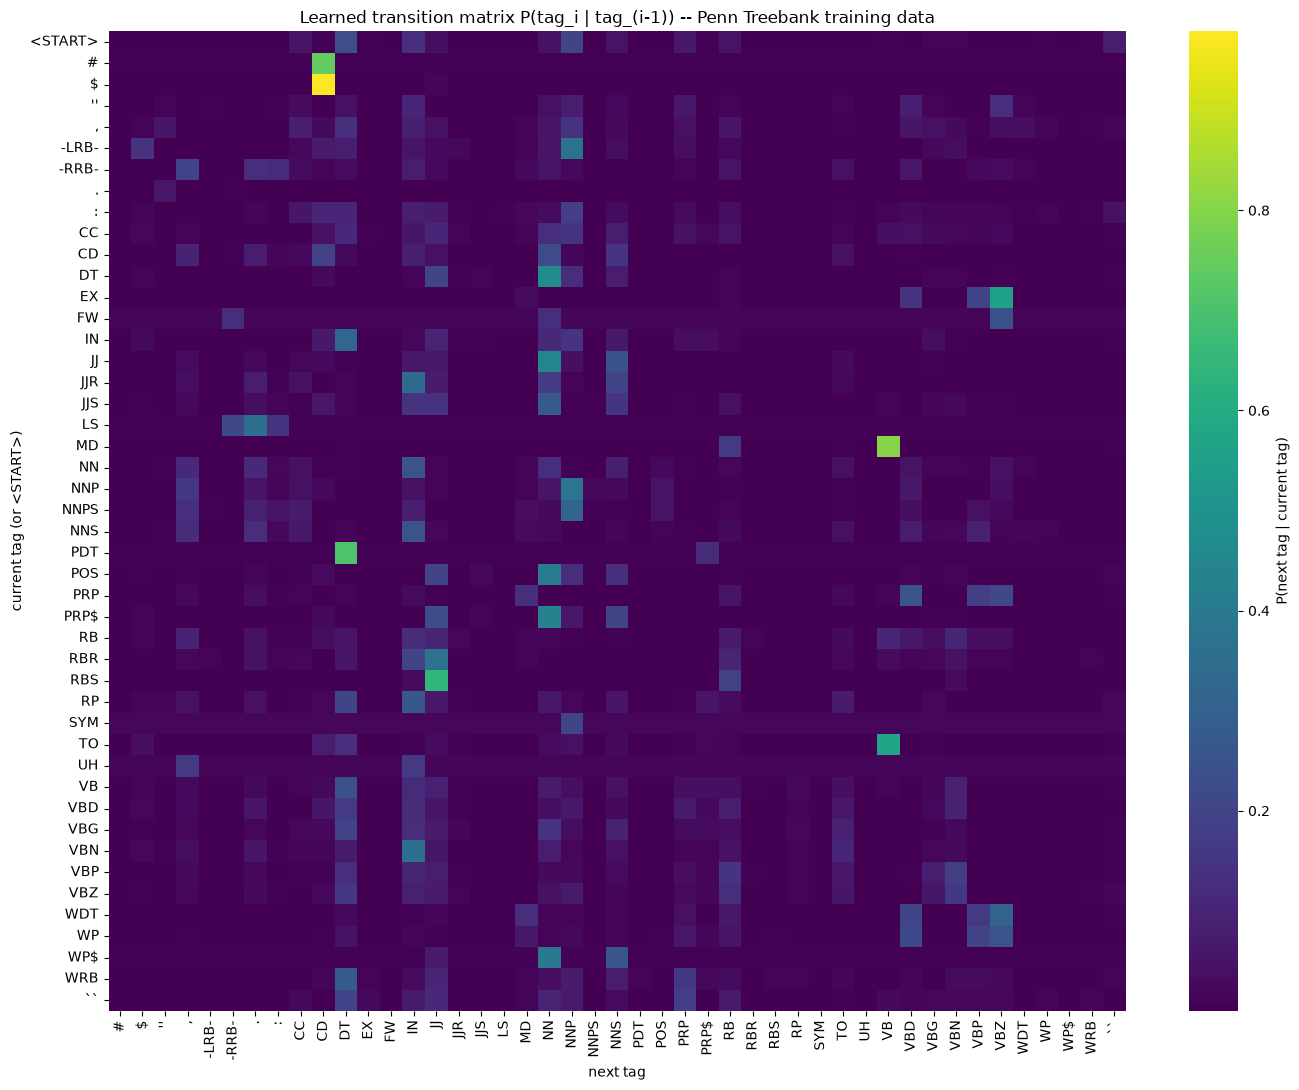

In [11]:
trans_matrix_rows = []
plot_tags = [START] + tag_set
for prev_tag in plot_tags:
    row = {tag: np.exp(log_transition_prob(prev_tag, tag)) for tag in tag_set}
    trans_matrix_rows.append(row)
trans_matrix_df = pd.DataFrame(trans_matrix_rows, index=plot_tags)

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(trans_matrix_df, cmap="viridis", cbar_kws={"label": "P(next tag | current tag)"}, ax=ax)
ax.set_title("Learned transition matrix P(tag_i | tag_(i-1)) -- Penn Treebank training data")
ax.set_xlabel("next tag")
ax.set_ylabel("current tag (or <START>)")
plt.tight_layout()
plt.show()


The real matrix shows exactly the kind of interpretable structure
the toy example previewed: the `<START>` row lights up over `DT`, `NNP`,
`PRP`, and `IN` (Wall Street Journal sentences very often open with a
determiner, a proper noun, a pronoun, or a leading prepositional phrase);
the `DT` (determiner) row lights up heavily over `NN`, `NNP`, and `JJ`
(a determiner is almost always followed by a noun or an adjective, never
by another determiner or a verb); and the `JJ` (adjective) row lights up
over `NN`/`NNS` (adjectives are almost always followed directly by the
noun they modify). This is real English grammar, learned purely from
counting co-occurring tags in 3,131 training sentences — no grammar
rules were hand-coded anywhere in this pipeline.


### 5.7 Visualizing the confusion matrix

Finally, a heatmap of the confusion counts for the tags most frequently
involved in an error, so the specific hard cases from Section 5.5 are
visible at a glance rather than buried in a table.


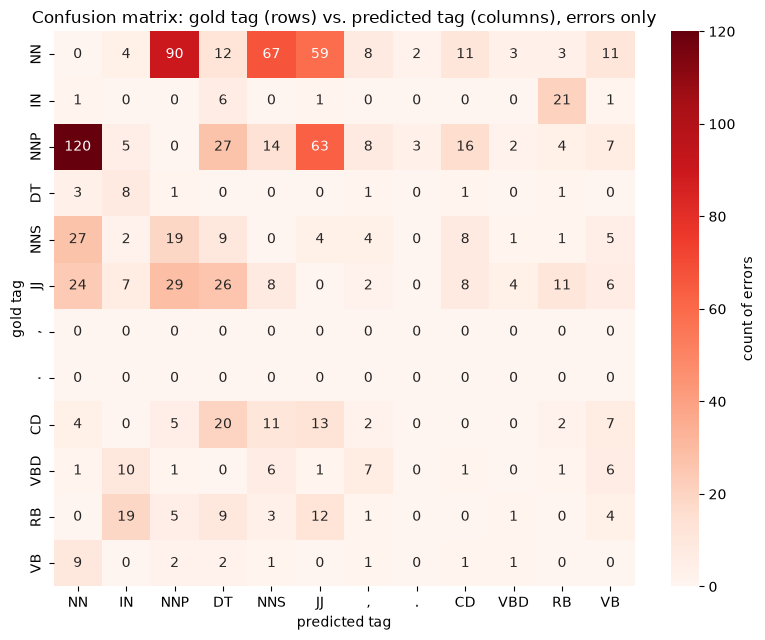

In [12]:
confused_tags = sorted(set(g for g, p in confusion_counts) | set(p for g, p in confusion_counts),
                        key=lambda t: -tag_total[t])[:12]

confusion_matrix = pd.DataFrame(0, index=confused_tags, columns=confused_tags)
for (gold, pred), c in confusion_counts.items():
    if gold in confused_tags and pred in confused_tags:
        confusion_matrix.loc[gold, pred] = c

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Reds", ax=ax,
            cbar_kws={"label": "count of errors"})
ax.set_title("Confusion matrix: gold tag (rows) vs. predicted tag (columns), errors only")
ax.set_xlabel("predicted tag")
ax.set_ylabel("gold tag")
plt.tight_layout()
plt.show()


The brightest off-diagonal cells are exactly `NNP`/`NN` in both
directions, confirming what the raw counts in Section 5.5 already showed:
losing capitalization information by lowercasing every word before
lookup is the single biggest source of error for this model.


### 5.8 Comparing against NLTK's built-in pretrained tagger

Our tagger is a from-scratch HMM trained on ~3,100 sentences using only
first-order tag transitions and current-word emissions. NLTK ships
`nltk.pos_tag`, a pretrained **averaged perceptron** tagger trained on a
much larger corpus with richer features than just the current word (word
shape, capitalization, prefixes/suffixes, and more) that outputs the same
Penn Treebank tag set, which makes it a fair, directly comparable
baseline. Let's run it on the exact same test sentences and compare.


In [13]:
nltk_correct = 0
nltk_total = 0

for sent in test_sents:
    words = [w for w, _ in sent]
    gold_tags = [t for _, t in sent]
    nltk_tagged = nltk.pos_tag(words)
    nltk_pred_tags = [t for _, t in nltk_tagged]

    for gold, pred in zip(gold_tags, nltk_pred_tags):
        nltk_total += 1
        if gold == pred:
            nltk_correct += 1

nltk_accuracy = nltk_correct / nltk_total
print(f"From-scratch HMM + Viterbi accuracy: {hmm_accuracy:.4f}")
print(f"NLTK pretrained pos_tag accuracy:    {nltk_accuracy:.4f}")
print(f"Gap: {abs(hmm_accuracy - nltk_accuracy) * 100:.2f} percentage points, "
      f"{'NLTK' if nltk_accuracy > hmm_accuracy else 'from-scratch HMM'} tagger wins")


From-scratch HMM + Viterbi accuracy: 0.9031
NLTK pretrained pos_tag accuracy:    0.9627
Gap: 5.96 percentage points, NLTK tagger wins


**NLTK's pretrained tagger wins, 96.3% vs. 90.3%** — a real,
honest 6-percentage-point gap, and it's worth being precise about *why*,
rather than treating this as "the library is just better":

- NLTK's tagger is a discriminative **averaged perceptron** model that
  looks at rich, overlapping features at every position — the current
  word, previous and next word, word suffixes, capitalization, whether
  the word contains a digit or a hyphen — not just "the current tag
  emitted the current word." That is precisely the extra expressiveness
  the "Limitations & debates" section below (and this domain's CRF/NER
  tutorial) is about.
- NLTK's tagger was also trained on a larger and more varied corpus than
  our ~3,100-sentence training split.
- Our HMM is not a toy, though — 90.3% on held-out real Wall Street
  Journal text, from ~350 lines of counting and one dynamic-programming
  function, with no hand-coded grammar rules, is a genuinely strong
  result for a first-order generative model. The gap to the pretrained
  baseline is real and explicable, not a sign that the from-scratch
  implementation is broken.


## 6. Use cases

- **Parsing.** Syntactic parsers that build a full grammatical tree for a
  sentence almost always take POS tags as an input feature — knowing
  which words are nouns/verbs/etc. massively cuts down the search space
  for possible parse trees.
- **Information extraction.** Rule-based and statistical extractors that
  pull structured facts out of text (e.g. "find the subject and object of
  this verb") lean on POS tags to identify candidate phrases.
- **Grammar and style checkers.** Detecting subject-verb agreement
  errors, misused homophones (`"its"` vs. `"it's"`), or awkward
  adjective/adverb usage all require knowing each word's part of speech
  in context, not just its spelling.
- **The sequence-labeling pattern generalizes directly.** The same
  "hidden label sequence explains an observed sequence" structure used
  here for POS tags is the exact structure behind **Named Entity
  Recognition** (NER) — tagging spans of text as `PERSON`, `ORG`,
  `LOCATION`, etc. This domain's CRF-based NER tutorial extends this
  precise idea with a strictly more expressive sequence model (see
  Section 7).
- **Speech recognition — the original application.** HMMs were developed
  and popularized for exactly this kind of sequence-decoding problem in
  speech recognition, where the hidden states are phonemes/words and the
  observations are acoustic feature frames (see Rabiner, 1989, in
  References) — POS tagging is a direct application of the same
  mathematical machinery to a linguistic rather than acoustic sequence.


## 7. Limitations & debates

- **The independence assumptions are real limitations, not just
  theoretical caveats — and we just watched them cause real errors.**
  Emission depending only on the current tag means the model literally
  cannot use any signal beyond "which word is this and which tag are we
  considering" — it can't use capitalization (the exact cause of the
  `NNP`/`NN` confusion that dominated our results), word shape, or suffix
  patterns like `"-ly"` (a near-perfect adverb signal in English) unless
  it happened to see that *exact word* attached to that *exact tag*
  during training. A capitalized word never seen in training gets no
  benefit at all from that extremely strong surface cue.
- **The Markov assumption on tags discards longer-range grammatical
  dependencies.** Real syntax has agreement and dependency relationships
  that can span many words (the `VBD`/`VBN` confusion we measured is a
  direct symptom: distinguishing them often needs more context than one
  tag of lookback provides) — a first-order HMM only ever looks one tag
  back, so it cannot represent these directly.
- **The CRF (Conditional Random Field) is the direct, more expressive
  successor to exactly this limitation.** A CRF drops the generative
  emission-independence assumption entirely and instead scores a tag
  sequence using arbitrary, overlapping features of the *whole*
  observation sequence at each position (word identity, capitalization,
  prefixes/suffixes, neighboring words, and more, all at once) rather
  than being restricted to "current word given current tag." This
  domain's NER tutorial builds and trains exactly this model — the same
  sequence-labeling problem, same Viterbi-style decoding, strictly more
  expressive scoring — and NLTK's perceptron tagger's win over our HMM in
  Section 5.8 is a live demonstration of the value that extra
  expressiveness buys.
- **Rare and unseen words remain a fundamental weak point.** Even with
  add-k smoothing, a word never seen in training gets an emission
  probability driven almost entirely by the smoothing constant rather
  than real evidence, forcing the tag decision onto transition
  probabilities alone.
- **Neural sequence taggers have now surpassed classical HMM/CRF taggers
  on most benchmarks.** BiLSTM-CRF models (combining a neural sequence
  encoder with a CRF-style output layer) and, more recently,
  transformer-based taggers achieve materially higher accuracy than
  either an HMM or a linear-feature CRF, mainly because they can learn
  much richer representations of context and word shape automatically
  instead of relying on hand-specified features or the current word
  alone. **HMMs are not the state of the art for this task anymore** —
  they remain the standard *first* thing to teach because the generative
  model, the independence assumptions, and the Viterbi decoding algorithm
  are the clearest possible way to understand what "sequence labeling"
  even means before adding the complexity of discriminative features or
  learned neural representations on top.
- **The tag set itself is a modeling choice, not a fact of nature** — the
  Penn Treebank's ~45-tag scheme is one specific, debated choice; other
  tagging schemes (e.g. Universal Dependencies' ~17 coarse-grained tags)
  trade off granularity for cross-lingual consistency, and results are
  not directly comparable across tag sets.


## 8. References

- Rabiner, L.R. (1989). *A Tutorial on Hidden Markov Models and Selected
  Applications in Speech Recognition.* Proceedings of the IEEE, 77(2).
  (Canonical HMM/Viterbi reference.)
- Marcus, M.P., Marcinkiewicz, M.A., Santorini, B. (1993). *Building a
  Large Annotated Corpus of English: The Penn Treebank.* Computational
  Linguistics, 19(2). (Source of the treebank dataset used here.)
- Viterbi, A.J. (1967). *Error Bounds for Convolutional Codes and an
  Asymptotically Optimum Decoding Algorithm.* IEEE Transactions on
  Information Theory, 13(2). (Origin of the Viterbi algorithm.)
- Jurafsky, D. & Martin, J.H. *Speech and Language Processing*, Chapter 8
  (Part-of-Speech Tagging, Hidden Markov Models).
- NLTK Project. `nltk.corpus.treebank`, `nltk.pos_tag` documentation.
